## NLP–GWAS companion notebook (DH2026)

This notebook implements the **GWAS-inspired stylometric workflow** (*From Genes to Tokens*): token frequencies are treated as quantitative traits; each type (word or punctuation token) is tested for association with a binary label (here: text chunks whose metadata contain **Wells** versus all other chunks in the English lemma corpus).

**Pipeline (high level)**

1. Load lemmatised plain-text files from `data/lemmas/English_25_3`.
2. Optionally **chunk** long texts so that each segment fits the vectoriser; each chunk is a separate row in the design matrix.
3. Fit **`sklearn`** `CountVectorizer` + `TfidfVectorizer(use_idf=False)` to obtain per-chunk TF values (same role as relative frequencies; controlled by `max_features`, `min_df`).
4. For each token, fit **logistic regression** of label ~ standardised frequency; collect coefficient (beta) and p-value.
5. Apply **multiple-testing correction** (Bonferroni in the cell below; you may switch to `method="fdr_bh"` if your preregistered analysis uses FDR).
6. Visualise **Manhattan-style** and **volcano** plots (Plotly) and check calibration via **QQ plot** and genomic-control-style **lambda**.

**Dependencies:** `scikit-learn`, `statsmodels`, `pandas`, `numpy`, `plotly`, `matplotlib`, `scipy`, `tqdm`.


In [14]:
import os
import re

import numpy as np
import pandas as pd
import statsmodels.api as sm
import tqdm
from matplotlib import pyplot as plt
import plotly.express as px
from scipy.stats import chi2
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from statsmodels.stats.multitest import multipletests


In [15]:
def clear_text(text: str) -> str:
    """Keep Cyrillic/Latin letters (with diacritics), digits, and selected punctuation."""
    clean_text = re.sub(r"[^А-яа-яA-Za-zÀ-ÖØ-öø-ÿ0-9.,!?:;-]", " ", text)
    clean_text = re.sub(r"\s+", " ", clean_text)
    return clean_text.strip()

In [16]:
# Chunking tokenizer matches the vectoriser `token_pattern` below.
CHUNK_SIZE = 10000
OVERLAP = 0

_token_re = re.compile(r"(?u)\w+|[^\w\s]")


def chunk_text_by_tokens(text: str, chunk_size: int = 10000, overlap: int = 0):
    """Split text into chunks of `chunk_size` tokens; optional overlap for sliding windows."""
    toks = _token_re.findall(text)
    if chunk_size <= 0:
        raise ValueError("chunk_size must be > 0")
    if overlap < 0 or overlap >= chunk_size:
        raise ValueError("overlap must be >= 0 and < chunk_size")

    chunks = []
    step = chunk_size - overlap if chunk_size > overlap else 1
    for start in range(0, len(toks), step):
        end = start + chunk_size
        if start >= len(toks):
            break
        chunk_tokens = toks[start:end]
        if not chunk_tokens:
            break
        chunks.append(" ".join(chunk_tokens))
        if end >= len(toks):
            break
    return chunks


data = {"author": [], "title": [], "date": [], "text": []}

directory = os.path.join("data", "lemmas", "English_25_3")
for filename in tqdm.tqdm(os.listdir(directory)):
    path = os.path.join(directory, filename)
    if not os.path.isfile(path):
        continue

    with open(path, encoding="utf-8") as file:
        author = filename.split(".")[0]
        raw = file.read()
        cleaned = clear_text(raw)
        chunks = chunk_text_by_tokens(cleaned, chunk_size=CHUNK_SIZE, overlap=OVERLAP)
        base_title = ".".join(filename.split('.')[:-1])

        for i, ch in enumerate(chunks, start=1):
            data["author"].append(author)
            data["title"].append(f"{base_title} [chunk {i}]")
            data["text"].append(ch)

TOKEN_PATTERN = r"[А-Яа-яA-Za-z]+|[^\w\s]"

# Vocabulary + corpus-wide counts
cv = CountVectorizer(
    token_pattern=TOKEN_PATTERN,
    ngram_range=(1, 1),
    max_features=5000,
    min_df=0.05,
)
X_cnt = cv.fit_transform(data["text"])

# TF without IDF (same transformer family as TF–IDF, idf disabled)
tf = TfidfVectorizer(
    vocabulary=cv.vocabulary_,
    token_pattern=TOKEN_PATTERN,
    ngram_range=(1, 1),
    use_idf=False,
)
X_tf = tf.fit_transform(data["text"])

terms = cv.get_feature_names_out()
counts = np.asarray(X_cnt.sum(axis=0)).ravel()
# rows = token types, columns = chunk frequencies
Xt = X_tf.T
df = pd.concat(
    [
        pd.DataFrame({"Count": counts, "Word": terms}),
        pd.DataFrame(Xt.toarray(), columns=data["title"]),
    ],
    axis=1,
)
df = df.sort_values(by="Count", ascending=False).reset_index(drop=True)
booknames = data["title"]
authors = data["author"]


100%|██████████| 75/75 [00:07<00:00,  9.45it/s]


In [17]:
df

,Count,Word,"Benson, Arthur Christopher, 1862-1925.The House of Quiet An Autobiography by Arthur Christopher Benson.Неизвестно [chunk 1]","Benson, Arthur Christopher, 1862-1925.The House of Quiet An Autobiography by Arthur Christopher Benson.Неизвестно [chunk 2]","Benson, Arthur Christopher, 1862-1925.The House of Quiet An Autobiography by Arthur Christopher Benson.Неизвестно [chunk 3]","Benson, Arthur Christopher, 1862-1925.The House of Quiet An Autobiography by Arthur Christopher Benson.Неизвестно [chunk 4]","Benson, Arthur Christopher, 1862-1925.The House of Quiet An Autobiography by Arthur Christopher Benson.Неизвестно [chunk 5]","Benson, Arthur Christopher, 1862-1925.The House of Quiet An Autobiography by Arthur Christopher Benson.Неизвестно [chunk 6]","Benson, Arthur Christopher, 1862-1925.The House of Quiet An Autobiography by Arthur Christopher Benson.Неизвестно [chunk 7]","Benson, Arthur Christopher, 1862-1925.The Isles of Sunset by Arthur Christopher Benson.Неизвестно [chunk 1]",...,"Yonge, Charlotte M. (Charlotte Mary), 1823-1901.Dynevor Terrace; Or, The Clue of Life — Volume 2 by Charlotte M. Yonge.Неизвестно [chunk 6]","Yonge, Charlotte M. (Charlotte Mary), 1823-1901.Dynevor Terrace; Or, The Clue of Life — Volume 2 by Charlotte M. Yonge.Неизвестно [chunk 7]","Yonge, Charlotte M. (Charlotte Mary), 1823-1901.Dynevor Terrace; Or, The Clue of Life — Volume 2 by Charlotte M. Yonge.Неизвестно [chunk 8]","Yonge, Charlotte M. (Charlotte Mary), 1823-1901.Dynevor Terrace; Or, The Clue of Life — Volume 2 by Charlotte M. Yonge.Неизвестно [chunk 9]","Yonge, Charlotte M. (Charlotte Mary), 1823-1901.Dynevor Terrace; Or, The Clue of Life — Volume 2 by Charlotte M. Yonge.Неизвестно [chunk 10]","Yonge, Charlotte M. (Charlotte Mary), 1823-1901.Dynevor Terrace; Or, The Clue of Life — Volume 2 by Charlotte M. Yonge.Неизвестно [chunk 11]","Yonge, Charlotte M. (Charlotte Mary), 1823-1901.Dynevor Terrace; Or, The Clue of Life — Volume 2 by Charlotte M. Yonge.Неизвестно [chunk 12]","Yonge, Charlotte M. (Charlotte Mary), 1823-1901.Dynevor Terrace; Or, The Clue of Life — Volume 2 by Charlotte M. Yonge.Неизвестно [chunk 13]","Yonge, Charlotte M. (Charlotte Mary), 1823-1901.Dynevor Terrace; Or, The Clue of Life — Volume 2 by Charlotte M. Yonge.Неизвестно [chunk 14]","Yonge, Charlotte M. (Charlotte Mary), 1823-1901.Dynevor Terrace; Or, The Clue of Life — Volume 2 by Charlotte M. Yonge.Неизвестно [chunk 15]"
0,546137,",",0.548870,0.564612,0.552341,0.503004,0.570204,0.470975,0.248661,0.492757,...,0.592186,0.612965,0.599592,0.552214,0.580170,0.571845,0.597031,0.615726,0.601636,0.479170
1,403021,.,0.193343,0.187164,0.270468,0.286844,0.205306,0.335695,0.607837,0.196059,...,0.275149,0.292589,0.302731,0.305462,0.271495,0.286346,0.300626,0.271281,0.294662,0.423576
2,356498,the,0.456193,0.428918,0.393482,0.409307,0.464343,0.462625,0.193403,0.452501,...,0.346605,0.291771,0.316987,0.302058,0.337208,0.281263,0.276982,0.284434,0.314361,0.393131
3,257544,be,0.270840,0.230836,0.264765,0.284378,0.204504,0.226302,0.193403,0.182641,...,0.275970,0.283598,0.281766,0.323330,0.264578,0.291429,0.324271,0.272103,0.283992,0.223701
4,229520,and,0.246073,0.244873,0.240325,0.245749,0.264652,0.232147,0.110516,0.307880,...,0.285005,0.268070,0.263317,0.293550,0.255067,0.265167,0.249115,0.235933,0.239669,0.234290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,70,ominous,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4996,70,luminous,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000745,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4997,70,hung,0.000000,0.000000,0.000000,0.000000,0.000802,0.000000,0.000000,0.000000,...,0.000000,0.000817,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4998,70,carpenter,0.000000,0.000000,0.0000

In [18]:
author1 = df.loc[:, df.columns.str.contains('Wells')]
author2 = df.loc[:, ~df.columns.str.contains('Wells')]
author2 = author2[author2.columns[2:]]

In [19]:
betas = []
pvalues = []

y = np.array([1]*author1.shape[1] + [0]*author2.shape[1])
# y = np.random.permutation(y) # uncomment for permutation test

for i in tqdm.tqdm(range(len(df['Word']))):
    X_raw = np.concatenate([
        author1.loc[i].values.astype(float),
        author2.loc[i].values.astype(float)
    ])

    # Skip fully constant features
    if np.std(X_raw) == 0:
        betas.append(np.nan)
        pvalues.append(np.nan)
        continue

    X_std = (X_raw - X_raw.mean()) / X_raw.std()
    X = sm.add_constant(X_std)

    try:
        # Classic logistic regression
        # Note: In cases of (quasi-)complete separation, logistic regression may produce
        # extremely large coefficient estimates. This is statistically valid (MLE → ∞),
        # but indicates that the predictor perfectly separates the classes rather than a stable finite effect. 
        model = sm.Logit(y, X).fit(disp=False)
        # We can use Regularized logistic regression to handle it
        # But it is not recommended because of p-values estimation bias
        # model = sm.Logit(y, X).fit_regularized(
        #     method='l1',
        #     alpha=1,
        #     disp=False)
        # Check convergence
        if not model.mle_retvals.get("converged", False):
            beta = np.nan
            pval = np.nan
        else:
            beta = model.params[1]      # Word coefficient
            pval = model.pvalues[1]
    except Exception:
        beta = np.nan
        pval = np.nan

    betas.append(beta)
    pvalues.append(pval)


 10%|█         | 506/5000 [00:01<00:09, 488.09it/s]c:\Users\User\.conda\envs\py312-work\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning:

overflow encountered in exp

c:\Users\User\.conda\envs\py312-work\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

 11%|█         | 555/5000 [00:01<00:09, 484.44it/s]c:\Users\User\.conda\envs\py312-work\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning:

overflow encountered in exp

c:\Users\User\.conda\envs\py312-work\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

 12%|█▏        | 604/5000 [00:01<00:09, 472.53it/s]c:\Users\User\.conda\envs\py312-work\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning:

overflow encountered in exp

c:\Users\User\.conda\envs\py312-work\Lib\site-package

In [20]:
results = pd.DataFrame({'SNP': df['Word'], 'beta': betas, 'p': pvalues})
results

,SNP,beta,p
0,",",-1.654376,2.171147e-19
1,.,1.993985,6.731665e-15
2,the,0.070498,6.295117e-01
3,be,0.341779,2.636720e-02
4,and,0.945720,1.677570e-10
...,...,...,...
4995,ominous,-0.167182,4.156806e-01
4996,luminous,0.186718,5.856410e-02
4997,hung,-0.060181,7.227455e-01
4998,carpenter,-0.149284,5.905798e-01


In [21]:
# Bonferroni correction (FWER). Use method="fdr_bh" for Benjamini–Hochberg FDR.
rej, p_adj, _, _ = multipletests(results["p"].values, method="bonferroni")
results["p_adj"] = p_adj
results["significant"] = rej


In [22]:
# === 4) Select significant associations (tokens as SNPs) ===
# results = results[results["significant"]].sort_values("p_adj").iloc[1:]
sig_df = results[results["significant"]].sort_values("p_adj")
print(f"Significant tokens (Bonferroni): {sig_df.shape[0]}")
sig_df[["SNP", "beta", "p", "p_adj"]]

Significant tokens (Bonferroni): 244


,SNP,beta,p,p_adj
2484,anyhow,1.284784,5.337527e-22,2.668763e-18
352,sort,2.074438,6.441982e-22,3.220991e-18
160,these,1.519109,4.506764e-21,2.253382e-17
168,world,1.240762,9.740614e-20,4.870307e-16
98,thing,1.416456,1.295366e-19,6.476832e-16
...,...,...,...,...
1719,religion,0.380430,9.098704e-06,4.549352e-02
1548,extraordinary,0.472560,9.217969e-06,4.608985e-02
1532,german,0.428687,9.305387e-06,4.652693e-02
2577,moustache,0.393507,9.336755e-06,4.668378e-02


In [23]:
# Working copy
df_plot = results.copy().reset_index(drop=False)
df_plot.rename(columns={"index": "idx"}, inplace=True)

# -log10(p)
df_plot["minus_log10_p"] = -np.log10(df_plot["p"].clip(lower=1e-300))

# Ensure required columns exist
if "significant" not in df_plot.columns:
    df_plot["significant"] = False
if "beta" not in df_plot.columns:
    raise ValueError("DataFrame has no column 'beta'")

# Reference line: most significant p still passing the multiple-testing rule
if df_plot["significant"].any():
    p_thresh = df_plot.loc[df_plot["significant"], "p"].max()
    sig_line = -np.log10(p_thresh)
else:
    p_thresh = None
    sig_line = None

# === Colour by significance and beta sign ===
def classify_row(row):
    if not row["significant"]:
        return "non-significant"        # grey
    if row["beta"] > 0:
        return "beta-positive"          # green
    else:
        return "beta-negative"          # red

df_plot["effect_group"] = df_plot.apply(classify_row, axis=1)

color_map = {
    "non-significant": "lightgray",
    "beta-positive": "green",
    "beta-negative": "red",
}

# === Plotly Scatter ===
fig = px.scatter(
    df_plot,
    x="idx",
    y="minus_log10_p",
    color="effect_group",
    color_discrete_map=color_map,
    hover_data={
        "idx": True,
        "SNP": True,
        "p": ":.3e",
        "beta": ":.4f",
        "significant": True,
        "minus_log10_p": ":.2f",
        "effect_group": True,
    },
    labels={
        "idx": "Token index",
        "minus_log10_p": "-log10(p)",
        "effect_group": "Effect type",
    },
    title="Manhattan plot",
)

# Significance threshold line
if sig_line is not None:
    fig.add_hline(
        y=sig_line,
        line_dash="dash",
        line_color="purple",
        annotation_text=f"(p = {p_thresh:.2e})",
        annotation_position="top left"
    )

# Marker styling
fig.update_traces(marker=dict(size=6, opacity=0.75))

fig.update_layout(
    template="plotly_white",
    hoverlabel=dict(bgcolor="white", font_size=12),
    margin=dict(l=40, r=20, t=60, b=40),
)

fig.show()


In [24]:
# How many points to label
TOP_N_LABELS = 20   # increase/decrease for more/fewer labels

# Working copy
df_plot = results.copy().reset_index(drop=False)
df_plot.rename(columns={"index": "idx"}, inplace=True)

# -log10(p)
df_plot["minus_log10_p"] = -np.log10(df_plot["p"].clip(lower=1e-300))

# Ensure required columns exist
if "significant" not in df_plot.columns:
    df_plot["significant"] = False
if "beta" not in df_plot.columns:
    raise ValueError("DataFrame has no column 'beta'")

# Significance threshold line
if df_plot["significant"].any():
    p_thresh = df_plot.loc[df_plot["significant"], "p"].max()
    sig_line = -np.log10(p_thresh)
else:
    p_thresh = None
    sig_line = None

# Colour classification
def classify_row(row):
    if not row["significant"]:
        return "non-significant"
    if row["beta"] > 0:
        return "beta-positive"
    else:
        return "beta-negative"

df_plot["effect_group"] = df_plot.apply(classify_row, axis=1)

color_map = {
    "non-significant": "lightgray",
    "beta-positive": "green",
    "beta-negative": "red",
}

# ==== Labels for TOP_N_LABELS highest -log10(p) points (any beta sign) ====
df_plot["label"] = ""  # empty unless top-N

top_idx = (
    df_plot
    .nlargest(TOP_N_LABELS, "minus_log10_p")  # no filter by significant/beta
    .index
)
df_plot.loc[top_idx, "label"] = df_plot.loc[top_idx, "SNP"]

# === Plotly Scatter ===
fig = px.scatter(
    df_plot,
    x="idx",
    y="minus_log10_p",
    color="effect_group",
    color_discrete_map=color_map,
    text="label",   # labels only for labelled points
    hover_data={
        "idx": True,
        "SNP": True,
        "p": ":.3e",
        "beta": ":.4f",
        "significant": True,
        "minus_log10_p": ":.2f",
        "effect_group": True,
    },
    labels={
        "idx": "Token index",
        "minus_log10_p": "-log10(p)",
        "effect_group": "Effect type",
    },
    title="Manhattan plot",
)

fig.update_traces(
    textposition="top center",
    textfont=dict(size=9),
    marker=dict(size=6, opacity=0.75),
)

# Significance threshold line
if sig_line is not None:
    fig.add_hline(
        y=sig_line,
        line_dash="dash",
        line_color="purple",
        annotation_text=f"(p = {p_thresh:.2e})",
        annotation_position="top left"
    )

fig.update_layout(
    template="plotly_white",
    hoverlabel=dict(bgcolor="white", font_size=12),
    margin=dict(l=40, r=20, t=60, b=40),
)

fig.show()

# ===== Export high-resolution figures =====
# Requires: pip install -U kaleido
fig.write_image("manhattan_wells.png", scale=5)
fig.write_image("manhattan_wells.svg")


In [25]:
# Working copy
df_volc = results.copy()

# Validate required columns
if "beta" not in df_volc.columns:
    raise ValueError("DataFrame has no column 'beta'")
if "significant" not in df_volc.columns:
    df_volc["significant"] = False

# -log10(p)
df_volc["minus_log10_p"] = -np.log10(df_volc["p"].clip(lower=1e-300))

# Horizontal line at multiple-testing threshold
if df_volc["significant"].any():
    p_thresh = df_volc.loc[df_volc["significant"], "p"].max()
    sig_line = -np.log10(p_thresh)
else:
    p_thresh = None
    sig_line = None

# --- Classify by effect sign and significance ---
def classify(row):
    if not row["significant"]:
        return "non-significant"
    return "beta-positive" if row["beta"] > 0 else "beta-negative"

df_volc["effect_group"] = df_volc.apply(classify, axis=1)

color_map = {
    "non-significant": "lightgray",
    "beta-positive": "green",
    "beta-negative": "red",
}

# --- Interactive volcano plot ---
fig = px.scatter(
    df_volc,
    x="beta",
    y="minus_log10_p",
    color="effect_group",
    color_discrete_map=color_map,
    hover_data={
        "SNP": True,           # token
        "p": ":.3e",
        "beta": ":.4f",
        "significant": True,
        "minus_log10_p": ":.2f",
        "effect_group": True,
    },
    labels={
        "beta": "β (logistic regression)",
        "minus_log10_p": "-log10(p)",
        "effect_group": "Effect type",
    },
    title="Volcano plot (interactive)",
)

# Vertical line at β = 0
fig.add_vline(
    x=0,
    line_dash="dash",
    line_color="black",
    annotation_text="β = 0",
    annotation_position="top left"
)

# # Raw p = 0.05 line
# p05_line = -np.log10(0.05)
# fig.add_hline(
#     y=p05_line,
#     line_dash="dot",
#     line_color="gray",
#     annotation_text="p = 0.05",
#     annotation_position="bottom right"
# )

# Threshold line (matches correction above)
if sig_line is not None:
    fig.add_hline(
        y=sig_line,
        line_dash="dash",
        line_color="purple",
        annotation_text=f"Bonferroni threshold (p = {p_thresh:.2e})",
        annotation_position="top right"
    )

fig.update_traces(marker=dict(size=7, opacity=0.75))

fig.update_layout(
    template="plotly_white",
    hoverlabel=dict(bgcolor="white", font_size=12),
    margin=dict(l=40, r=20, t=60, b=40),
)

fig.show()


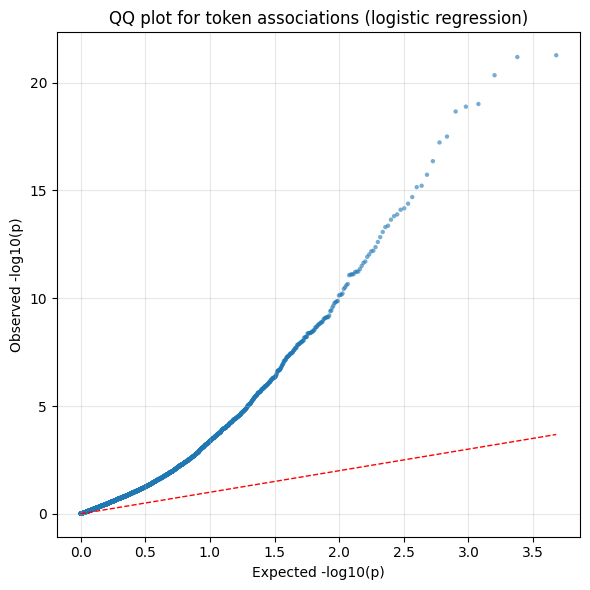

In [26]:
# === 1. Expect DataFrame "results" with column "p" ===
# Clip extreme values if needed:
pvals = results["p"].clip(lower=1e-300).dropna().values

# === 2. Sort observed p and compute expected under the null ===
pvals_sorted = np.sort(pvals)
n = len(pvals_sorted)
expected = -np.log10(np.linspace(1/n, 1, n))
observed = -np.log10(pvals_sorted)

# === 3. QQ plot ===
plt.figure(figsize=(6, 6))
plt.scatter(expected, observed, s=10, alpha=0.6, edgecolor='none')

# Diagonal (perfect calibration)
plt.plot([0, max(expected)], [0, max(expected)], color='red', lw=1, linestyle='--')

plt.xlabel("Expected -log10(p)")
plt.ylabel("Observed -log10(p)")
plt.title("QQ plot for token associations (logistic regression)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

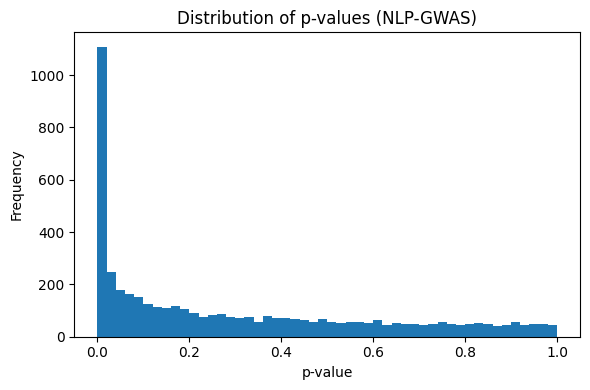

In [27]:
def plot_p_hist(results, p_col="p", title="Histogram of p-values"):
    pvals = results[p_col].dropna()
    
    plt.figure(figsize=(6, 4))
    plt.hist(pvals, bins=50, range=(0, 1))
    plt.xlabel("p-value")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_p_hist(results, p_col="p", title="Distribution of p-values (NLP-GWAS)")

In [28]:
def calculate_lambda_gc(pvalues):
    # Drop non-finite p-values; clamp to avoid log/sqrt edge cases.
    p = np.asarray(pvalues)
    p = p[np.isfinite(p)]
    p = np.clip(p, 1e-300, 1.0)

    # χ² statistic for df = 1
    chi2_stats = chi2.isf(p, df=1)   # isf = inverse survival function = χ²^{-1}(1-p)

    # Median observed χ²
    median_chi2 = np.median(chi2_stats)

    # Theoretical median χ²(1)
    median_chi2_null = chi2.ppf(0.5, df=1)  # ≈ 0.455

    lambda_gc = median_chi2 / median_chi2_null
    return lambda_gc

lambda_gc = calculate_lambda_gc(results["p"])
lambda_gc


3.6980454323504857